In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score



import tensorflow as tf

import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# =====================================================
# 1️⃣ 데이터 로드
# =====================================================
csv_path = "C:/ai/1month/data/new_flight_weather_merged.csv"
df = pd.read_csv(csv_path)

print("✅ CSV 로드 완료")
print("전체 행 수:", len(df))

C:\Users\Admin\AppData\Local\Temp\ipykernel_6416\1882693962.py:5: DtypeWarning: Columns (31,52) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


✅ CSV 로드 완료
전체 행 수: 2836872


In [3]:
# =====================================================
# 2️⃣ 상태 == '지연' 데이터만 사용
# -----------------------------------------------------
# ✔ 지연시간 회귀는 '지연이 발생한 항공편'만 의미가 있음
# ✔ 정상/결항/회항 데이터는 회귀 대상이 아님
# =====================================================
reg_df = df[df["상태"] == "지연"].copy()
print("⏱ 상태=지연 데이터 수:", len(reg_df))

⏱ 상태=지연 데이터 수: 480982


In [4]:
# =====================================================
# 3️⃣ 지연_분 분포 확인 (정제 전)
# -----------------------------------------------------
# ✔ 데이터 이상치/결측치 여부 파악 목적
# =====================================================
print("📊 정제 전 지연_분 분포")
print(reg_df["지연_분"].describe())

📊 정제 전 지연_분 분포
count    480982.000000
mean         57.602601
std          42.985101
min       -1414.000000
25%          36.000000
50%          46.000000
75%          64.000000
max        1391.000000
Name: 지연_분, dtype: float64


In [5]:
# =====================================================
# 4️⃣ 지연_분 정제
# -----------------------------------------------------
# ✔ y(target)에 NaN이 있으면 모델 학습 불가
# ✔ 음수 지연은 논리적으로 불가능
# =====================================================

# ❗ 지연_분 NaN 제거 (가장 중요)
reg_df = reg_df[reg_df["지연_분"].notna()]

# ❗ 음수 제거
reg_df = reg_df[reg_df["지연_분"] >= 0].copy()

print("📊 음수 + NaN 제거 후 지연_분 분포")
print(reg_df["지연_분"].describe())

📊 음수 + NaN 제거 후 지연_분 분포
count    480517.000000
mean         57.753488
std          41.523529
min           0.000000
25%          36.000000
50%          46.000000
75%          65.000000
max        1391.000000
Name: 지연_분, dtype: float64


In [6]:
# =====================================================
# 5️⃣ 지연시간 상한 컷
# -----------------------------------------------------
# ✔ 360분(6시간) 이상은 이벤트성 지연
# ✔ 회귀 모델 안정화를 위해 상한 적용
# =====================================================
MAX_DELAY = 360
reg_df = reg_df[reg_df["지연_분"] <= MAX_DELAY].copy()

print("📊 상한 컷 후 지연_분 분포")
print(reg_df["지연_분"].describe())


📊 상한 컷 후 지연_분 분포
count    479429.000000
mean         56.744999
std          34.943600
min           0.000000
25%          36.000000
50%          46.000000
75%          64.000000
max         360.000000
Name: 지연_분, dtype: float64


In [7]:
# =====================================================
# 6️⃣ Feature 정의 (도착지 코드화 포함, arrival_code는 cat_cols)
# =====================================================

if "arrival_code" in reg_df.columns:
    reg_df["arrival_code"] = (
        pd.to_numeric(reg_df["arrival_code"], errors="coerce")
          .fillna(-1)
          .astype(int)
          .astype(str)   # ✅ cat_cols로 쓸 거면 문자열 고정
    )
elif "도착지" in reg_df.columns:
    tmp = pd.to_numeric(reg_df["도착지"], errors="coerce")
    if tmp.notna().mean() > 0.7:
        reg_df["arrival_code"] = tmp.fillna(-1).astype(int).astype(str)  # ✅
    else:
        reg_df["arrival_code"] = (
            reg_df["도착지"].astype("category").cat.codes.astype(int).astype(str)  # ✅
        )
else:
    raise KeyError("⚠️ '도착지' 또는 'arrival_code' 컬럼이 없습니다.")

num_cols = ["기온(°C)", "풍속_ms", "dep_hour", "dep_weekday", "is_weekend"]
cat_cols = ["공항명", "출발지", "flight_type", "arrival_code"]

num_cols = [c for c in num_cols if c in reg_df.columns]
cat_cols = [c for c in cat_cols if c in reg_df.columns]

# ✅ 여기서는 굳이 category로 안 바꿔도 됨(오히려 충돌 줄어듦)
# for c in cat_cols:
#     reg_df[c] = reg_df[c].astype("category")

X_cols = num_cols + cat_cols

print("✅ num_cols:", num_cols)
print("✅ cat_cols:", cat_cols)
print("✅ X_cols:", X_cols)
print("✅ arrival_code dtype:", reg_df["arrival_code"].dtype)


✅ num_cols: ['기온(°C)', '풍속_ms', 'dep_hour', 'dep_weekday', 'is_weekend']
✅ cat_cols: ['공항명', '출발지', 'flight_type', 'arrival_code']
✅ X_cols: ['기온(°C)', '풍속_ms', 'dep_hour', 'dep_weekday', 'is_weekend', '공항명', '출발지', 'flight_type', 'arrival_code']
✅ arrival_code dtype: object


In [8]:
# =====================================================
# 7️⃣ 시간 기준 Train / Test 분리
# -----------------------------------------------------
# ✔ 미래 정보 누수 방지
# ✔ 실제 운영 상황과 동일한 분리 방식
# =====================================================
reg_df["departure_datetime"] = pd.to_datetime(reg_df["departure_datetime"], errors="coerce")
reg_df = reg_df[reg_df["departure_datetime"].notna()].copy()

split_date = reg_df["departure_datetime"].quantile(0.8)

train_df = reg_df[reg_df["departure_datetime"] <= split_date]
test_df  = reg_df[reg_df["departure_datetime"] > split_date]

X_train = train_df[X_cols]
y_train = train_df["지연_분"]

X_test  = test_df[X_cols]
y_test  = test_df["지연_분"]

print("Train:", len(X_train), "Test:", len(X_test))

Train: 383544 Test: 95885


In [9]:
# =====================================================
# 8️⃣ y(target) NaN 사전 점검 및 제거
# -----------------------------------------------------
# ✔ y에 NaN이 있으면 모델 학습 불가
# ✔ X와 y를 동시에 정제하여 인덱스 불일치 방지
# =====================================================
print("y_train NaN 수:", y_train.isna().sum())
print("y_test  NaN 수:", y_test.isna().sum())

train_mask = y_train.notna()
test_mask  = y_test.notna()

X_train = X_train.loc[train_mask]
y_train = y_train.loc[train_mask]

X_test  = X_test.loc[test_mask]
y_test  = y_test.loc[test_mask]

print("NaN 제거 후 Train:", len(X_train), "Test:", len(X_test))

y_train NaN 수: 0
y_test  NaN 수: 0
NaN 제거 후 Train: 383544 Test: 95885


In [10]:
# =====================================================
# 9️⃣ 전처리 파이프라인
# -----------------------------------------------------
# ✔ 수치형: 중앙값 대치
# ✔ 범주형: UNKNOWN + One-Hot Encoding
# =====================================================
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="UNKNOWN")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])


In [11]:
# =====================================================
# 🔟 Deep Learning Regression (MLP) - 전처리 동일 적용
# -----------------------------------------------------
# ✔ sklearn ColumnTransformer(preprocessor) 그대로 사용
# ✔ 희소행렬(one-hot) -> Dense 변환 (너무 넓으면 SVD로 축소 옵션)
# =====================================================
import numpy as np
import tensorflow as tf
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import mean_absolute_error, mean_squared_error

# (재현성)
np.random.seed(42)
tf.random.set_seed(42)

# 1) 전처리(동일) 적용
X_train_pp = preprocessor.fit_transform(X_train)
X_test_pp  = preprocessor.transform(X_test)

print("전처리 후 shape:", X_train_pp.shape)

# 2) 희소행렬 처리
USE_SVD_IF_WIDE = True      # 원-핫 특성이 너무 많으면 자동으로 SVD로 줄임
SVD_THRESHOLD = 20000       # 특성 개수 임계값
SVD_COMPONENTS = 512        # 축소 차원(필요시 조절)

if USE_SVD_IF_WIDE and X_train_pp.shape[1] > SVD_THRESHOLD:
    print(f"[INFO] 특성 개수({X_train_pp.shape[1]})가 커서 TruncatedSVD({SVD_COMPONENTS})로 축소합니다.")
    svd = TruncatedSVD(n_components=SVD_COMPONENTS, random_state=42)
    X_train_pp = svd.fit_transform(X_train_pp)
    X_test_pp  = svd.transform(X_test_pp)
else:
    # sparse -> dense (메모리 큰 경우 주의)
    if hasattr(X_train_pp, "toarray"):
        X_train_pp = X_train_pp.toarray()
        X_test_pp  = X_test_pp.toarray()

X_train_pp = X_train_pp.astype(np.float32)
X_test_pp  = X_test_pp.astype(np.float32)

y_train_np = y_train.values.astype(np.float32)
y_test_np  = y_test.values.astype(np.float32)

print("학습 입력 shape:", X_train_pp.shape)

# 3) tf.data Dataset
BATCH_SIZE = 256

train_ds = tf.data.Dataset.from_tensor_slices((X_train_pp, y_train_np)) \
    .shuffle(min(len(X_train_pp), 20000), seed=42) \
    .batch(BATCH_SIZE) \
    .prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test_pp, y_test_np)) \
    .batch(BATCH_SIZE) \
    .prefetch(tf.data.AUTOTUNE)

# 4) 모델 정의
input_dim = X_train_pp.shape[1]

dl_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(input_dim,)),
    tf.keras.layers.Dense(256, activation="relu"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(1),
])

dl_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")],
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6),
]

# 5) 학습
history = dl_model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=200,
    callbacks=callbacks,
    verbose=1,
)

# 6) 평가
y_pred_dl = dl_model.predict(X_test_pp, batch_size=BATCH_SIZE).reshape(-1)

print("📊 Deep Learning Regression (MLP)")
print("MAE :", mean_absolute_error(y_test_np, y_pred_dl))
print("RMSE:", np.sqrt(mean_squared_error(y_test_np, y_pred_dl)))


전처리 후 shape: (383544, 38)
학습 입력 shape: (383544, 38)
Epoch 1/200
1499/1499 [==============================] - 5s 3ms/step - loss: 1173.7550 - mae: 21.5376 - val_loss: 922.9479 - val_mae: 20.0811 - lr: 0.0010
Epoch 2/200
1499/1499 [==============================] - 4s 3ms/step - loss: 1095.5647 - mae: 20.7889 - val_loss: 915.3224 - val_mae: 19.7913 - lr: 0.0010
Epoch 3/200
1499/1499 [==============================] - 4s 3ms/step - loss: 1086.6434 - mae: 20.7215 - val_loss: 915.1064 - val_mae: 18.2189 - lr: 0.0010
Epoch 4/200
1499/1499 [==============================] - 4s 3ms/step - loss: 1079.7626 - mae: 20.6668 - val_loss: 922.2725 - val_mae: 17.8961 - lr: 0.0010
Epoch 5/200
1499/1499 [==============================] - 4s 3ms/step - loss: 1074.2166 - mae: 20.6260 - val_loss: 905.8263 - val_mae: 18.8850 - lr: 0.0010
Epoch 6/200
1499/1499 [==============================] - 4s 3ms/step - loss: 1070.2874 - mae: 20.5824 - val_loss: 911.2138 - val_mae: 18.3508 - lr: 0.0010
Epoch 7/200
1499/1

In [12]:
# =====================================================
# 1️⃣1️⃣ Log-Deep Learning Regression (선택)
# -----------------------------------------------------
# ✔ 지연시간 long-tail 대응: log1p로 학습 -> expm1로 복원
# ✔ 마지막에 y_pred를 이 결과로 덮어써서 아래 결과표에 반영
# =====================================================
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# log 변환
y_train_log = np.log1p(y_train_np)
y_test_log  = np.log1p(y_test_np)

BATCH_SIZE = 256

train_ds_log = tf.data.Dataset.from_tensor_slices((X_train_pp, y_train_log)) \
    .shuffle(min(len(X_train_pp), 20000), seed=42) \
    .batch(BATCH_SIZE) \
    .prefetch(tf.data.AUTOTUNE)

test_ds_log = tf.data.Dataset.from_tensor_slices((X_test_pp, y_test_log)) \
    .batch(BATCH_SIZE) \
    .prefetch(tf.data.AUTOTUNE)

# 모델(새로) - 구조 동일
dl_model_log = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_pp.shape[1],)),
    tf.keras.layers.Dense(256, activation="relu"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(1),
])

dl_model_log.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")],
)

history_log = dl_model_log.fit(
    train_ds_log,
    validation_data=test_ds_log,
    epochs=200,
    callbacks=callbacks,
    verbose=1,
)

# 예측(log) -> 복원
y_pred_log = dl_model_log.predict(X_test_pp, batch_size=BATCH_SIZE).reshape(-1)
y_pred = np.expm1(y_pred_log)  # ✅ 아래 결과표에 쓰일 최종 예측값

print("📊 Log-Deep Learning Regression")
print("MAE :", mean_absolute_error(y_test_np, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test_np, y_pred)))


Epoch 1/200
1499/1499 [==============================] - 5s 3ms/step - loss: 0.3522 - mae: 0.4258 - val_loss: 0.7191 - val_mae: 0.7485 - lr: 0.0010
Epoch 2/200
1499/1499 [==============================] - 4s 3ms/step - loss: 0.1904 - mae: 0.3294 - val_loss: 0.4256 - val_mae: 0.5248 - lr: 0.0010
Epoch 3/200
1499/1499 [==============================] - 4s 3ms/step - loss: 0.1763 - mae: 0.3165 - val_loss: 0.3309 - val_mae: 0.4359 - lr: 0.0010
Epoch 4/200
1499/1499 [==============================] - 4s 3ms/step - loss: 0.1691 - mae: 0.3099 - val_loss: 0.2336 - val_mae: 0.3392 - lr: 0.0010
Epoch 5/200
1499/1499 [==============================] - 4s 3ms/step - loss: 0.1660 - mae: 0.3077 - val_loss: 0.1598 - val_mae: 0.2959 - lr: 0.0010
Epoch 6/200
1499/1499 [==============================] - 4s 3ms/step - loss: 0.1635 - mae: 0.3057 - val_loss: 0.1590 - val_mae: 0.3033 - lr: 0.0010
Epoch 7/200
1499/1499 [==============================] - 4s 3ms/step - loss: 0.1629 - mae: 0.3051 - val_loss: 0.

In [13]:
# ✅ 한글 폰트 설정 (그래프 그리기 전에 실행 추천)
# =====================================================
import os, warnings
import matplotlib.pyplot as plt
from matplotlib import font_manager, rcParams

def set_korean_font():
    candidates = ["Malgun Gothic", "맑은 고딕", "AppleGothic", "NanumGothic", "Noto Sans CJK KR", "Noto Sans KR"]
    for name in candidates:
        try:
            font_manager.findfont(name, fallback_to_default=False)
            rcParams["font.family"] = name
            return name
        except Exception:
            pass
    return rcParams.get("font.family", "sans-serif")

chosen = set_korean_font()
rcParams["axes.unicode_minus"] = False
warnings.filterwarnings("ignore", message=r"Glyph .* missing from current font.*")
print("✅ 적용된 폰트:", chosen)

✅ 적용된 폰트: Malgun Gothic


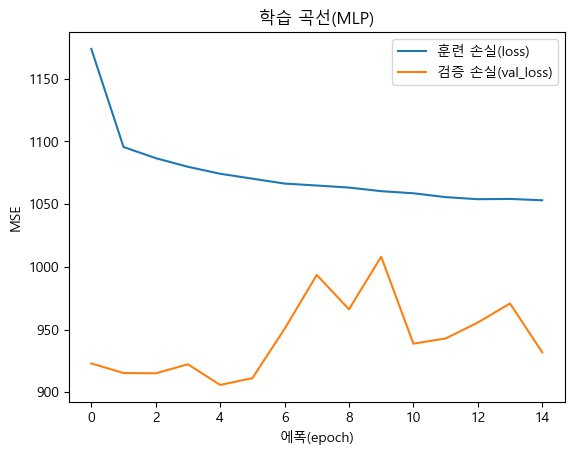

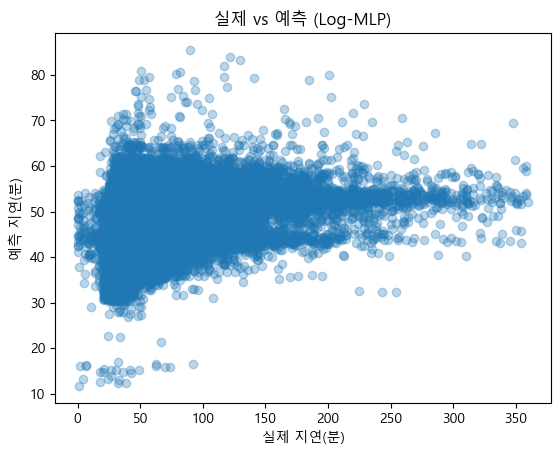

In [14]:
# =====================================================
# 1️⃣2️⃣ 학습 곡선 & 예측 산점도
# =====================================================
# 학습 곡선(기본 MLP)
plt.figure()
plt.plot(history.history.get("loss", []), label="훈련 손실(loss)")
plt.plot(history.history.get("val_loss", []), label="검증 손실(val_loss)")
plt.xlabel("에폭(epoch)")
plt.ylabel("MSE")
plt.legend()
plt.title("학습 곡선(MLP)")
plt.show()

# ✅ 예측값 자동 선택: Log-MLP(y_pred)가 있으면 그걸, 없으면 기본 MLP(y_pred_dl)
pred_final = y_pred if "y_pred" in globals() else y_pred_dl
pred_name  = "Log-MLP" if "y_pred" in globals() else "MLP"

plt.figure()
plt.scatter(y_test_np, pred_final, alpha=0.3)
plt.xlabel("실제 지연(분)")
plt.ylabel("예측 지연(분)")
plt.title(f"실제 vs 예측 ({pred_name})")
plt.show()

In [15]:
# =====================================================
# 1️⃣3️⃣ 예측 결과 확인
# =====================================================
result_df = pd.DataFrame({
    "actual_delay": y_test.values,
    "predicted_delay": pred_final
})

result_df.head(20)

,actual_delay,predicted_delay
0,71.0,52.964958
1,79.0,47.841358
2,95.0,52.964958
3,47.0,47.765888
4,154.0,52.964958
5,216.0,52.964958
6,91.0,52.964958
7,63.0,52.964958
8,29.0,47.841358
9,85.0,52.964958
